# Depth–Latitude Cross-Sections


This notebook examines the **vertical and meridional structure of ocean biogeochemical and physical variables** using depth–latitude cross-sections of anomalies across model simulations and observational products. It provides a configurable workflow for selecting variables, datasets, experiments, longitude ranges, depths, temporal periods, and seasonal selections; loading and preparing the corresponding data;  selecting longitude pointsranges; and visualizing the resulting latitude–depth structure. The latitude range is configured using **lat_min** and **lat_max** arguments.

The analysis can be used to compare the location, magnitude, and vertical extent of large-scale ocean features across datasets and experiments, with particular emphasis on the **tropical oceans** and their subsurface biogeochemical and physical structure.

The notebook follows four main stages:

1. **Package and configuration setup** – Load the required analysis, plotting, and project configuration utilities.
2. **Data request configuration** – Select variables, datasets/experiments, temporal periods, seasons, longitude ranges, latitude ranges, and vertical extent.
3. **Data loading and preparation** – Load and preprocess the requested datasets, select the analysis domain, and average across the specified longitude range to construct latitude–depth cross-sections.
4. **Visualization** – Generate depth–latitude cross-sections for comparison of the vertical and meridional structure across the selected datasets and experiments.

## Biomes

The biomes defined here are Pacific Equatorial (PEQ), PEQ East and West (PEQ-E, PEQ-W), and Atlantic Equatorial (AEQ). The latitude range is configurable.

## Optional configurations

1. **`calculate_ekman`** – Optionally calculate **Ekman transport** when the required wind-stress variables are available. This allows the wind-driven component of the upper-ocean circulation to be included in the depth–latitude analysis.

2. **`calculate_density`** – Optionally calculate **seawater density** when the required temperature and salinity fields are available. The derived density field can then be included alongside the physical and biogeochemical variables in the cross-section analysis.

3. **`mask_ENSO_events`** – Optionally restrict the analysis to selected **ENSO events**. The selected data can either be averaged by year and month or retain their time dimensions, allowing seasonal averages and cross-sections to be calculated subsequently. User can also request calculation of La Nina minus El Nino events which will be climatological averages across all months and events.


### Package and configuration setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(1, '/home/rpg002/BGC_skill')

import numpy as np
import configs
from prepare import (prepare_data_for_analysis, 
                    load_ONI,
                    get_ekman,
                    get_density,
                     calculate_climatology, 
                     get_enso_events,
                     experiment_finder,
                     mask_EQ,
                     create_eq_biomes,
                     mask_NESO_events)

from modules.plotting.module_plot_2D import snapshot_crossection, snapshot_crossection_quiver
from modules.analysis.module_data_load import load_biomes
from modules.data_info.module_data_info import biomes_module


In [3]:
units = configs.units
boundaries_dict = configs.boundaries_dict
model_lev_bounds = configs.model_lev_bounds
model_levels = configs.model_levels
unit_change_dics = configs.unit_change_dics
varx = configs.varx
ENSO = configs.ENSO
contourf = configs.contourf
pcolor_ranges = configs.pcolor_ranges

### User configs

In [ ]:
data_directory = '/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data'
biomes_directory =  "/space/hall7/sitestore/eccc/crd/cccma/users/rsa001/big_store/AI/FGCO2/data/biomes" 

assimilation_BGC_run_id = None
CanOE_assimilation_BGC_run_id = 1

var_list = ['wo', 'uo', 'vo']
experiment_list = ['observation','assimilation', 'historical']
model_list = ['CanESM5', 'CanESM5-CanOE']
lat_min = -10
lat_max = 10
 ## this could be a dictionary for each variable as they might have different sources or one source for all variables.
obs_source = 'SODA'
 
calculate_ekman: bool = True
calculate_density: bool = True

### Data Loading

In [5]:
dict_em_data, obs_mask, model_mask , mask_ocean_surface = prepare_data_for_analysis(var_list,
                            experiment_list,
                            model_list,
                            obs_source,
                            data_directory ,
                            unit_change_dics,
                            assimilation_BGC_run_id = None,
                            CanOE_assimilation_BGC_run_id = 1,
                            nldyr = 1, 
                            varx_dicts = varx,
                            target_levels=model_levels,
                            verbose = True)


observation directories: 

/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/wo/observation/SODA
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uo/observation/SODA
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/vo/observation/SODA

model directories: 

wo assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/wo/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/wo/assimilation/CanESM5-CanOE_1
wo historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/wo/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/wo/historical/CanESM5-CanOE
uo assimilation: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uo/assimilation/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uo/assimilation/CanESM5-CanOE_1
uo historical: 
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uo/historical/CanESM5
/space/hall7/sitestore/eccc/crd/cccma/users/rpg002/data/uo/historical/CanESM5-

In [ ]:
bms_info = biomes_module(biomes_directory)
bms_dict = bms_info.data_dict['biomes']
bms_dir  = bms_dict['dir']
bms_file = bms_dict['file']
bms_dict_plot = bms_info.dict_biomes_plot
nbms = 17
bms_labels = [bms_info.biomes_dict[ii]['label'] for ii in np.arange(nbms)+1]

biomes = load_biomes(f'{bms_dir}',
                     f'{bms_file}') * mask_ocean_surface

mask_biomes = create_eq_biomes(biomes, lat_max = lat_max, lat_min = lat_min)


loading global ocean biomes..
done


In [7]:
ONI_dict = load_ONI(experiment_list, 
                    model_list, 
                    assimilation_BGC_run_id,
                    CanOE_assimilation_BGC_run_id,
                    obs_source='SODA')

ElNino_dict, LaNina_dict = get_enso_events(ONI_dict)


In [8]:
idisplay=False

if idisplay:

    ax = plt.subplot(1,1,1)
    ax.pcolormesh(mask_ocean_surface.lon, mask_ocean_surface.lat, mask_ocean_surface.where(mask_ocean_surface ==0).values, vmin = 0, vmax =1)
    plt.scatter(-50.5, 43.5, color='red', s=10, label='My Point', zorder=10)

In [9]:
idisplay=False

if idisplay:
    print('checking loaded data')
    for var in dict_em_data:
        for exp in dict_em_data[var]:
            print(f'{var} {exp}')
            display(dict_em_data[var][exp].data)




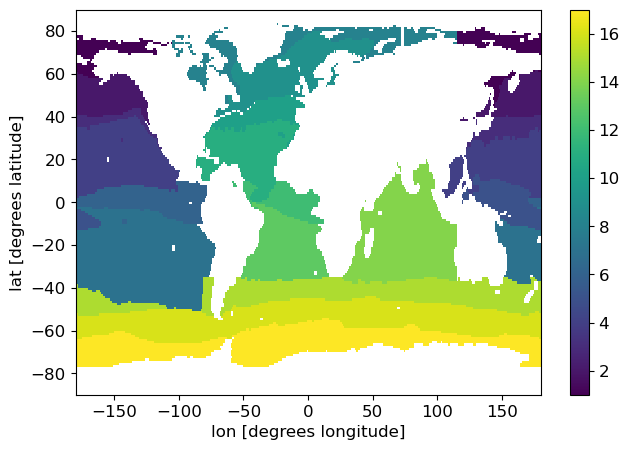

In [10]:
idisplay=True

if idisplay:
    (biomes.MeanBiomes * mask_ocean_surface ).where(biomes.MeanBiomes * mask_ocean_surface > 0).plot()


### Data Prep

In [11]:
if calculate_ekman:
    dict_em_data = get_ekman(dict_em_data)

if calculate_density: 
    dict_em_data = get_density(dict_em_data)

uas or vas does not exist. wE cannot be calculated.
so or thetao does not exist. Density cannot be calculated.


In [12]:
dict_em_clim, dict_em_anom = calculate_climatology(dict_em_data,
                                                   y0_base=None,
                                                   y1_base=None,
                                                   return_anomaly=True,
                                                   center_on_zero=True)
                                           

calculating wo CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...


done.
calculating wo CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating wo CanESM5-CMOC_historical climatology over 1980 - 2023 ...
done.
calculating wo CanESM5-CanOE_historical climatology over 1980 - 2023 ...
done.
calculating wo obs climatology over 1980 - 2023 ...
done.
calculating uo CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...
done.
calculating uo CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating uo CanESM5-CMOC_historical climatology over 1980 - 2023 ...
done.
calculating uo CanESM5-CanOE_historical climatology over 1980 - 2023 ...
done.
calculating uo obs climatology over 1980 - 2023 ...
done.
calculating vo CanESM5-CMOC_assimilation climatology over 1980 - 2023 ...
done.
calculating vo CanESM5-CanOE_1_assimilation climatology over 1980 - 2023 ...
done.
calculating vo CanESM5-CMOC_historical climatology over 1980 - 2023 ...
done.
calculating vo CanESM5-CanOE_historical climatology over 1980 - 2023 ...
done

In [13]:
dict_em_LaNina, dict_em_ElNino, dict_em_diff = mask_NESO_events(dict_em_anom,
                                                  ONI_dict,
                                                  calculate_mean = False,
                                                  upper_percentile=75,
                                                  lower_percentile=25,
                                                  return_diff=True)



In [14]:
dict_em_anom =  mask_EQ(dict_em_anom, mask_biomes)    
dict_em_LaNina = mask_EQ(dict_em_LaNina, mask_biomes) 
dict_em_ElNino = mask_EQ(dict_em_ElNino, mask_biomes) 
dict_em_diff = mask_EQ(dict_em_diff, mask_biomes) 

### Plots

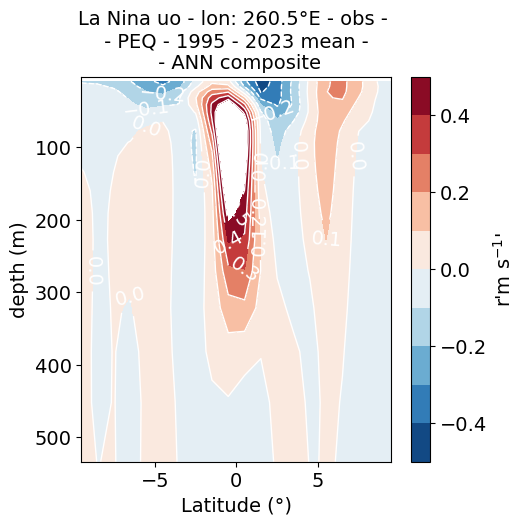

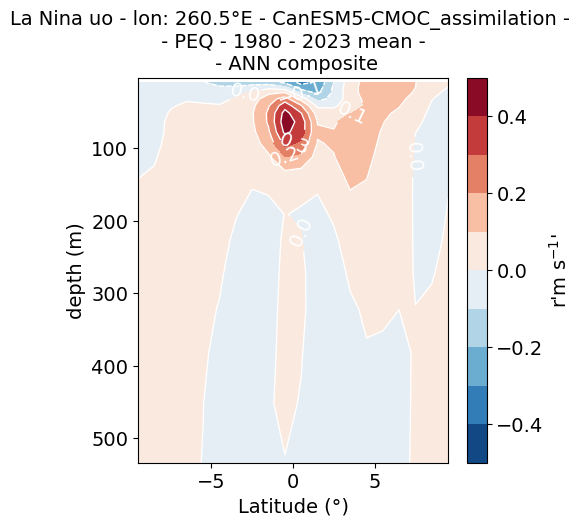

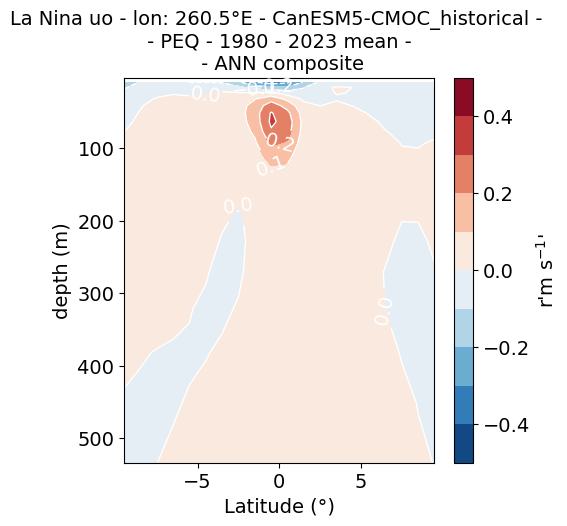

In [16]:
var = 'uo'

model_experiment = ['observation', 'CanESM5 assimilation', 'CanESM5 historical']
season_to_plot = 'ANN'
figsize = (5,5 )


title = f'La Nina {var}'
bms_label =  'PEQ'
colorbar_label = units[var]
lev_range = 600
longitude = 260

ds_dicts = dict_em_LaNina[var]
ds_list = experiment_finder(dict_em_data[var], model_experiment)

for ds in ds_list:

    snapshot_crossection(
        ds_list=[ds],
        ds_dicts=ds_dicts,
        biome=bms_label,
        longitude= longitude,
        title= title,
        contourf_levels=np.arange(-5,6) * 1e-1,
        cmap = 'RdBu_r',
        colorbar_label=colorbar_label,
        lev_range= lev_range,
        figsize=figsize
    )


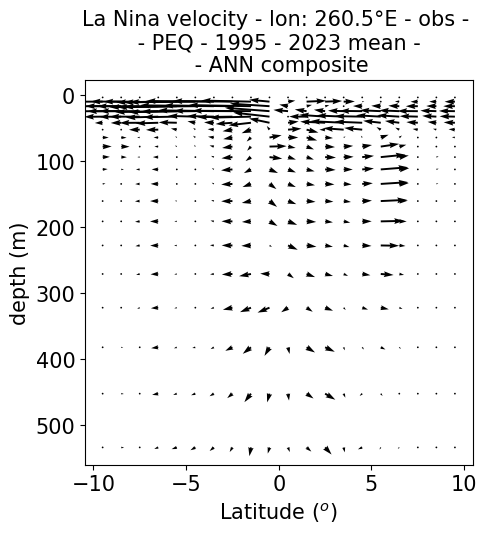

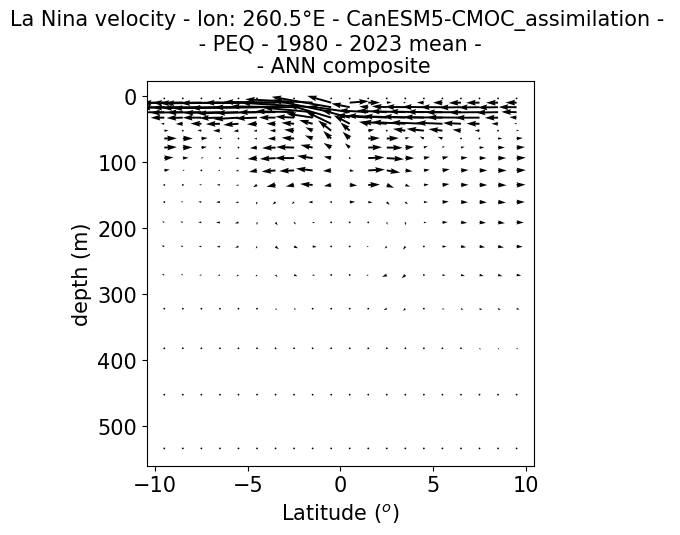

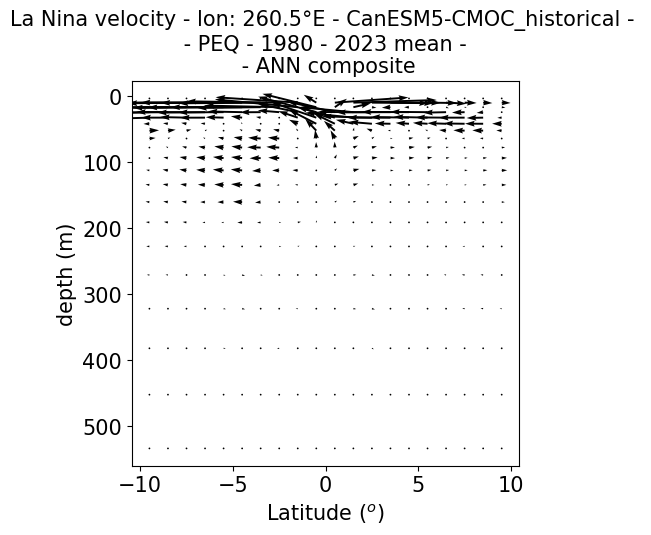

In [22]:
varx = 'vo'
vary = 'wo'
var_color = 'thetao'

model_experiment = ['observation', 'CanESM5 assimilation', 'CanESM5 historical']
season_to_plot = 'ANN'
figsize = (5,5 )


title = f'La Nina velocity'
bms_label =  'PEQ'
colorbar_label = units[var]
lev_range = 600
longitude = 260

ds_dicts_y = dict_em_LaNina[vary]
ds_dicts_x = dict_em_LaNina[varx]
colorbar_label = units[var_color]

ds_list = experiment_finder(dict_em_data[var], model_experiment)

for ds in ds_list:

    snapshot_crossection_quiver(
        ds_list=[ds],
        quiver_dicts_X=ds_dicts_x,
        quiver_dicts_Y=ds_dicts_y,
        biome=bms_label,
        longitude= longitude,
        title= title,
        lev_range= lev_range,
        figsize=figsize,
        width=  0.005,
        headwidth = 3,
        headlength = 5,
        headaxislength = 4.5,
        scale_factor_Y = 1000)




